# B1: Credit Scoring and PD Estimation
**Track:** Resume B - Quantitative Risk & Analytics
**Environment:** resume-b
**Started:** 2025-05
**Build Guide Reference:** AllProjectsBuildGuide.md — Section B1

In [1]:
# Imports and config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import os

matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
warnings.filterwarnings('ignore')

DATA_DIR = '../data/'
OUTPUT_DIR = '../outputs/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def savefig(filename, tight=True):
    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, bbox_inches='tight' if tight else None, dpi=150)
    print(f"Saved: {filename}")

print("Environment ready.")

Environment ready.


In [2]:
# Step 1: Load data and class distribution

df = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))

print("Shape:", df.shape)
print()

default_rate = df['TARGET'].mean()
class_counts = df['TARGET'].value_counts()

print("Class distribution:")
print(f"  Non-default (0): {class_counts[0]:,}  ({1 - default_rate:.1%})")
print(f"  Default     (1): {class_counts[1]:,}  ({default_rate:.1%})")
print()
print(f"Majority-class baseline accuracy: {max(default_rate, 1 - default_rate):.2%}")
print()
print("Column count by dtype:")
print(df.dtypes.value_counts())
print()
print("Missing value summary (top 15 columns by % missing):")
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0].head(15).round(2).to_string())

Shape: (307511, 122)

Class distribution:
  Non-default (0): 282,686  (91.9%)
  Default     (1): 24,825  (8.1%)

Majority-class baseline accuracy: 91.93%

Column count by dtype:
float64    65
int64      41
str        16
Name: count, dtype: int64

Missing value summary (top 15 columns by % missing):
COMMONAREA_AVG             69.8700
COMMONAREA_MODE            69.8700
COMMONAREA_MEDI            69.8700
NONLIVINGAPARTMENTS_MEDI   69.4300
NONLIVINGAPARTMENTS_MODE   69.4300
NONLIVINGAPARTMENTS_AVG    69.4300
FONDKAPREMONT_MODE         68.3900
LIVINGAPARTMENTS_AVG       68.3500
LIVINGAPARTMENTS_MEDI      68.3500
LIVINGAPARTMENTS_MODE      68.3500
FLOORSMIN_MODE             67.8500
FLOORSMIN_AVG              67.8500
FLOORSMIN_MEDI             67.8500
YEARS_BUILD_AVG            66.5000
YEARS_BUILD_MODE           66.5000


## Data Sources

| File | Source URL | Downloaded | Coverage |
|---|---|---|---|
| application_train.csv | https://www.kaggle.com/c/home-credit-default-risk | 2025-05-14 | 307,511 loan applications, 122 features, 8.1% default rate |

**Majority-class baseline accuracy: 91.93%**
All model performance claims are stated as lift over this baseline.

In [3]:
# Step 2: EDA feature setup

features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

subset = df[features + ['TARGET']].copy()

# DAYS_BIRTH is stored as negative (days before application)
# Convert to age in years for interpretability
subset['AGE_YEARS'] = subset['DAYS_BIRTH'].abs() / 365.25

# DAYS_EMPLOYED is negative for actual employees, positive outlier (365243)
# for pensioners/unemployed coded as a sentinel value — replace with NaN
subset['DAYS_EMPLOYED'] = subset['DAYS_EMPLOYED'].replace(365243, np.nan)
subset['YEARS_EMPLOYED'] = subset['DAYS_EMPLOYED'].abs() / 365.25

print("Feature summary:")
print(subset[features].describe().T[['count', 'mean', 'std', 'min', 'max']].round(2))
print()
print(f"DAYS_EMPLOYED sentinel (365243) replacements: "
      f"{(df['DAYS_EMPLOYED'] == 365243).sum():,}")

Feature summary:
                       count        mean         std         min  \
AMT_INCOME_TOTAL 307511.0000 168797.9200 237123.1500  25650.0000   
AMT_CREDIT       307511.0000 599026.0000 402490.7800  45000.0000   
DAYS_BIRTH       307511.0000 -16037.0000   4363.9900 -25229.0000   
DAYS_EMPLOYED    252137.0000  -2384.1700   2338.3600 -17912.0000   
EXT_SOURCE_1     134133.0000      0.5000      0.2100      0.0100   
EXT_SOURCE_2     306851.0000      0.5100      0.1900      0.0000   
EXT_SOURCE_3     246546.0000      0.5100      0.1900      0.0000   

                            max  
AMT_INCOME_TOTAL 117000000.0000  
AMT_CREDIT         4050000.0000  
DAYS_BIRTH           -7489.0000  
DAYS_EMPLOYED            0.0000  
EXT_SOURCE_1             0.9600  
EXT_SOURCE_2             0.8500  
EXT_SOURCE_3             0.9000  

DAYS_EMPLOYED sentinel (365243) replacements: 55,374


Saved: eda_default_rate_by_age.png


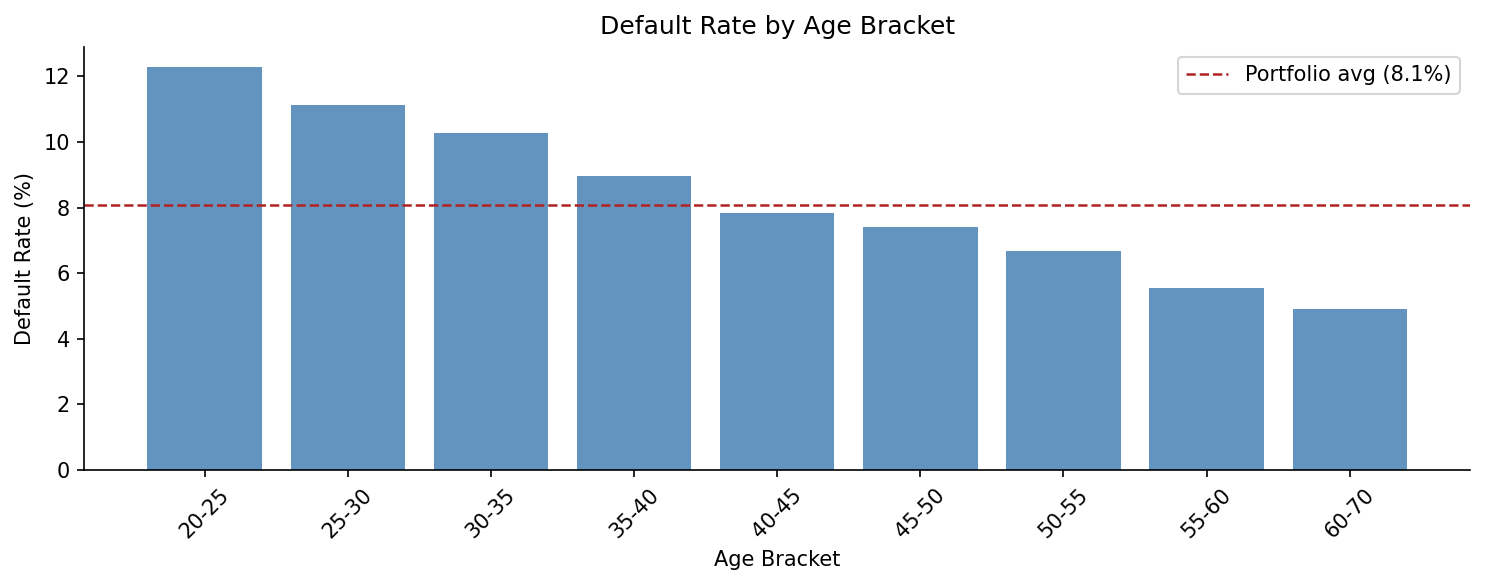

In [4]:
# Step 2: Default rate by age bracket

subset['AGE_BRACKET'] = pd.cut(subset['AGE_YEARS'],
                                bins=[20, 25, 30, 35, 40, 45, 50, 55, 60, 70],
                                labels=['20-25','25-30','30-35','35-40',
                                        '40-45','45-50','50-55','55-60','60-70'])

age_default = subset.groupby('AGE_BRACKET', observed=True)['TARGET'].agg(['mean', 'count'])
age_default.columns = ['default_rate', 'count']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(age_default)),
              age_default['default_rate'] * 100,
              color='steelblue', alpha=0.85)
ax.axhline(y=default_rate * 100, color='firebrick',
           linestyle='--', linewidth=1.2, label=f'Portfolio avg ({default_rate:.1%})')
ax.set_xticks(range(len(age_default)))
ax.set_xticklabels(age_default.index, rotation=45)
ax.set_xlabel('Age Bracket')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Age Bracket')
ax.legend()
plt.tight_layout()
savefig('eda_default_rate_by_age.png')
plt.show()

Saved: eda_default_rate_by_ext2_decile.png


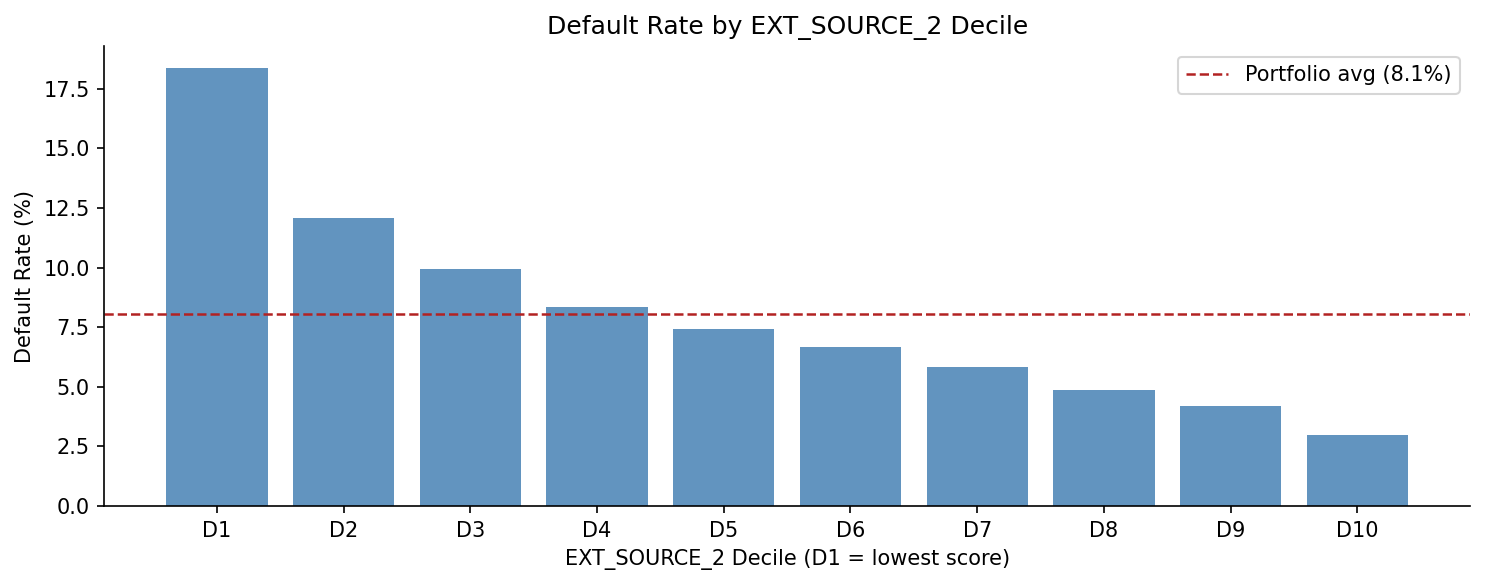

In [5]:
# Step 2: Default rate by EXT_SOURCE_2 decile

subset['EXT2_DECILE'] = pd.qcut(subset['EXT_SOURCE_2'].dropna(),
                                  q=10, labels=False, duplicates='drop')

ext2_default = subset.groupby('EXT2_DECILE')['TARGET'].agg(['mean', 'count'])
ext2_default.columns = ['default_rate', 'count']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(ext2_default)),
       ext2_default['default_rate'] * 100,
       color='steelblue', alpha=0.85)
ax.axhline(y=default_rate * 100, color='firebrick',
           linestyle='--', linewidth=1.2, label=f'Portfolio avg ({default_rate:.1%})')
ax.set_xticks(range(len(ext2_default)))
ax.set_xticklabels([f'D{i+1}' for i in range(len(ext2_default))])
ax.set_xlabel('EXT_SOURCE_2 Decile (D1 = lowest score)')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by EXT_SOURCE_2 Decile')
ax.legend()
plt.tight_layout()
savefig('eda_default_rate_by_ext2_decile.png')
plt.show()

Saved: eda_default_rate_by_income.png


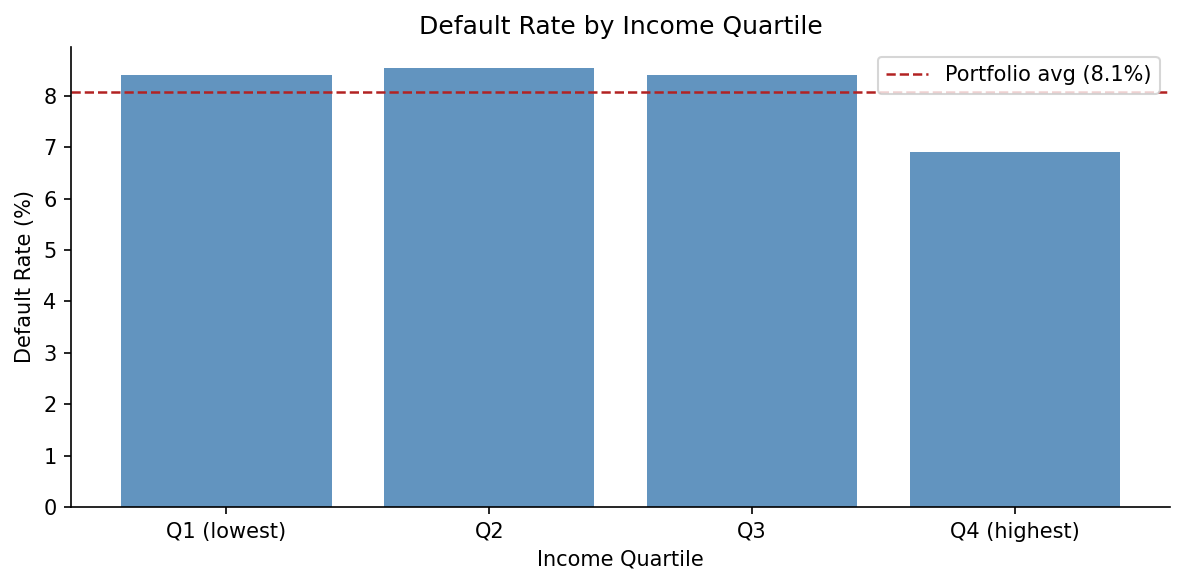

In [6]:
# Step 2: Default rate by income quartile

subset['INCOME_QUARTILE'] = pd.qcut(subset['AMT_INCOME_TOTAL'],
                                     q=4,
                                     labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

income_default = subset.groupby('INCOME_QUARTILE', observed=True)['TARGET'].agg(['mean', 'count'])
income_default.columns = ['default_rate', 'count']

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(income_default)),
       income_default['default_rate'] * 100,
       color='steelblue', alpha=0.85)
ax.axhline(y=default_rate * 100, color='firebrick',
           linestyle='--', linewidth=1.2, label=f'Portfolio avg ({default_rate:.1%})')
ax.set_xticks(range(len(income_default)))
ax.set_xticklabels(income_default.index)
ax.set_xlabel('Income Quartile')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Income Quartile')
ax.legend()
plt.tight_layout()
savefig('eda_default_rate_by_income.png')
plt.show()

In [7]:
# Step 2: Summary print

print("Default rate variation across features (signal check):")
print()
print("Age brackets:")
print(age_default[['default_rate', 'count']].to_string())
print()
print("EXT_SOURCE_2 deciles:")
print(ext2_default[['default_rate', 'count']].to_string())
print()
print("Income quartiles:")
print(income_default[['default_rate', 'count']].to_string())

Default rate variation across features (signal check):

Age brackets:
             default_rate  count
AGE_BRACKET                     
20-25              0.1229  12233
25-30              0.1113  32953
30-35              0.1027  39476
35-40              0.0896  42873
40-45              0.0783  41388
45-50              0.0742  35193
50-55              0.0667  34997
55-60              0.0554  33112
60-70              0.0492  35286

EXT_SOURCE_2 deciles:
             default_rate  count
EXT2_DECILE                     
0.0000             0.1835  30686
1.0000             0.1208  30685
2.0000             0.0996  30687
3.0000             0.0836  30684
4.0000             0.0742  30684
5.0000             0.0665  30687
6.0000             0.0585  30683
7.0000             0.0488  30694
8.0000             0.0420  30676
9.0000             0.0297  30685

Income quartiles:
                 default_rate   count
INCOME_QUARTILE                      
Q1 (lowest)            0.0839  100578
Q2             

In [8]:
# Step 3: WoE binning
import scorecardpy as sc

woe_features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'EXT_SOURCE_1',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

woe_df = df[woe_features + ['TARGET']].copy()
woe_df['DAYS_EMPLOYED'] = woe_df['DAYS_EMPLOYED'].replace(365243, np.nan)

print("Missing values per feature going into WoE binning:")
print(woe_df[woe_features].isnull().sum().to_string())
print()

bins = sc.woebin(woe_df, y='TARGET', method='tree',
                 ignore_datetime_cols=False,
                 replace_blank=False)
print("Binning complete.")

Missing values per feature going into WoE binning:
AMT_INCOME_TOTAL         0
AMT_CREDIT               0
DAYS_BIRTH               0
DAYS_EMPLOYED        55374
EXT_SOURCE_1        173378
EXT_SOURCE_2           660
EXT_SOURCE_3         60965

[INFO] creating woe binning ...
Binning on 307511 rows and 8 columns in 00:00:10
Binning complete.


In [9]:
# Step 3: inspect WoE bin tables
for feat in woe_features:
    print(f"\n{feat}:")
    print(bins[feat][['bin', 'count', 'count_distr', 'good', 'bad',
                       'badprob', 'woe', 'bin_iv']].to_string(index=False))


AMT_INCOME_TOTAL:
                bin  count  count_distr   good   bad  badprob     woe  bin_iv
    [-inf,220000.0) 239263       0.7781 219111 20152   0.0842  0.0462  0.0017
[220000.0,230000.0)  21423       0.0697  19800  1623   0.0758 -0.0689  0.0003
[230000.0,310000.0)  24639       0.0801  22903  1736   0.0705 -0.1472  0.0016
     [310000.0,inf)  22186       0.0721  20872  1314   0.0592 -0.3328  0.0070

AMT_CREDIT:
                 bin  count  count_distr  good   bad  badprob     woe  bin_iv
     [-inf,150000.0)  18159       0.0591 17066  1093   0.0602 -0.3157  0.0052
 [150000.0,300000.0)  72798       0.2367 67080  5718   0.0785 -0.0298  0.0002
 [300000.0,650000.0) 101606       0.3304 91315 10291   0.1013  0.2494  0.0228
 [650000.0,900000.0)  49790       0.1619 45980  3810   0.0765 -0.0581  0.0005
[900000.0,1350000.0)  48803       0.1587 45600  3203   0.0656 -0.2233  0.0072
     [1350000.0,inf)  16355       0.0532 15645   710   0.0434 -0.6602  0.0177

DAYS_BIRTH:
                bin

In [10]:
# Step 3: save WoE bin plots manually
import matplotlib.ticker as mtick

for feat in woe_features:
    bt = bins[feat].copy()
    bt['bin_label'] = bt['bin'].astype(str)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.bar(range(len(bt)), bt['woe'], color='steelblue', alpha=0.8, label='WoE')
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.set_ylabel('WoE')
    ax1.set_xticks(range(len(bt)))
    ax1.set_xticklabels(bt['bin_label'], rotation=30, ha='right', fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(range(len(bt)), bt['badprob'] * 100, color='firebrick',
             marker='o', linewidth=1.5, markersize=4, label='Default Rate %')
    ax2.set_ylabel('Default Rate (%)')
    ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))

    ax1.set_title(f'WoE Binning — {feat}')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

    plt.tight_layout()
    savefig(f'woe_{feat.lower()}.png')
    plt.close()

print("WoE plots saved.")

Saved: woe_amt_income_total.png
Saved: woe_amt_credit.png
Saved: woe_days_birth.png
Saved: woe_days_employed.png
Saved: woe_ext_source_1.png
Saved: woe_ext_source_2.png
Saved: woe_ext_source_3.png
WoE plots saved.


In [11]:
# Step 3: transform features to WoE values
woe_transformed = sc.woebin_ply(woe_df, bins, replace_blank=False)

print("WoE-transformed dataframe shape:", woe_transformed.shape)
print()
print("Columns:", [c for c in woe_transformed.columns if c != 'TARGET'])
print()
print("Sample (5 rows):")
print(woe_transformed.head().to_string())

[INFO] converting into woe values ...
WoE-transformed dataframe shape: (307511, 8)

Columns: ['EXT_SOURCE_3_woe', 'AMT_CREDIT_woe', 'DAYS_EMPLOYED_woe', 'AMT_INCOME_TOTAL_woe', 'DAYS_BIRTH_woe', 'EXT_SOURCE_2_woe', 'EXT_SOURCE_1_woe']

Sample (5 rows):
   TARGET  EXT_SOURCE_3_woe  AMT_CREDIT_woe  DAYS_EMPLOYED_woe  AMT_INCOME_TOTAL_woe  DAYS_BIRTH_woe  EXT_SOURCE_2_woe  EXT_SOURCE_1_woe
0       1            1.0187          0.2494             0.3571                0.0462          0.3745            0.3679            0.7570
1       0            0.1564         -0.2233             0.1829               -0.1472         -0.0953           -0.1902            0.1563
2       0           -0.9315         -0.3157             0.3571                0.0462         -0.0953           -0.1902            0.0587
3       0            0.1564          0.2494            -0.1377                0.0462         -0.0953           -0.1902            0.0587
4       0            0.1564          0.2494            -0.1377

In [13]:
# Step 4: compute IV and filter features
iv_rows = []
for feat, bt in bins.items():
    iv_rows.append({'variable': feat, 'info_value': bt['bin_iv'].sum()})

iv_table = (pd.DataFrame(iv_rows)
              .sort_values('info_value', ascending=False)
              .reset_index(drop=True))

print("Information Value by feature:")
print(iv_table.to_string(index=False))
print()

selected_features = iv_table[iv_table['info_value'] > 0.02]['variable'].tolist()
dropped_features  = iv_table[iv_table['info_value'] <= 0.02]['variable'].tolist()

print(f"Selected (IV > 0.02): {selected_features}")
print(f"Dropped  (IV <= 0.02): {dropped_features}")

Information Value by feature:
        variable  info_value
    EXT_SOURCE_3      0.3188
    EXT_SOURCE_2      0.2996
    EXT_SOURCE_1      0.1458
   DAYS_EMPLOYED      0.1090
      DAYS_BIRTH      0.0813
      AMT_CREDIT      0.0536
AMT_INCOME_TOTAL      0.0106

Selected (IV > 0.02): ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'AMT_CREDIT']
Dropped  (IV <= 0.02): ['AMT_INCOME_TOTAL']


In [14]:
# Step 4: build modelling dataframe with selected WoE features
selected_woe_cols = [f + '_woe' for f in selected_features]

model_df = woe_transformed[selected_woe_cols + ['TARGET']].copy()

print("Modelling dataframe shape:", model_df.shape)
print("Features entering model:", selected_woe_cols)

Modelling dataframe shape: (307511, 7)
Features entering model: ['EXT_SOURCE_3_woe', 'EXT_SOURCE_2_woe', 'EXT_SOURCE_1_woe', 'DAYS_EMPLOYED_woe', 'DAYS_BIRTH_woe', 'AMT_CREDIT_woe']


## Feature Selection

| Feature | IV | Band | Decision |
|---|---|---|---|
| EXT_SOURCE_3 | 0.319 | Strong | Selected |
| EXT_SOURCE_2 | 0.300 | Strong | Selected |
| EXT_SOURCE_1 | 0.146 | Medium | Selected |
| DAYS_EMPLOYED | 0.109 | Medium | Selected |
| DAYS_BIRTH | 0.081 | Weak-Medium | Selected |
| AMT_CREDIT | 0.054 | Weak-Medium | Selected |
| AMT_INCOME_TOTAL | 0.011 | Unpredictive | Dropped |

AMT_INCOME_TOTAL dropped: IV below 0.02 threshold. Raw income without
normalisation by loan amount carries negligible standalone predictive power.

In [15]:
# Step 5: train-test split
from sklearn.model_selection import train_test_split

X = model_df[selected_woe_cols]
y = model_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print(f"Train default rate: {y_train.mean():.4f}")
print(f"Test default rate:  {y_test.mean():.4f}")
print(f"Majority-class baseline (test set): {max(y_test.mean(), 1 - y_test.mean()):.4f}")

Train size: 215,257  |  Test size: 92,254
Train default rate: 0.0807
Test default rate:  0.0807
Majority-class baseline (test set): 0.9193


In [16]:
# Step 6: logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train, y_train)

print("Coefficients:")
for feat, coef in zip(selected_woe_cols, lr.coef_[0]):
    print(f"  {feat:<30s}  {coef:.4f}")
print(f"  Intercept: {lr.intercept_[0]:.4f}")

Coefficients:
  EXT_SOURCE_3_woe                0.8429
  EXT_SOURCE_2_woe                0.8356
  EXT_SOURCE_1_woe                0.6693
  DAYS_EMPLOYED_woe               0.5722
  DAYS_BIRTH_woe                  -0.0008
  AMT_CREDIT_woe                  0.5917
  Intercept: -0.0018


In [17]:
# Step 6: build scorecard
card = sc.scorecard(bins, lr, selected_features,
                    points0=600, odds0=1/20, pdo=50)

print("Scorecard point tables:")
for feat, tbl in card.items():
    print(f"\n{feat}:")
    print(tbl.to_string(index=False))

Scorecard point tables:

basepoints:
  variable  bin   points
basepoints  NaN 384.0000

EXT_SOURCE_3:
    variable                       bin   points
EXT_SOURCE_3                   missing -10.0000
EXT_SOURCE_3               [-inf,0.24) -62.0000
EXT_SOURCE_3               [0.24,0.42) -19.0000
EXT_SOURCE_3               [0.42,0.58)  14.0000
EXT_SOURCE_3 [0.58,0.7000000000000001)  38.0000
EXT_SOURCE_3  [0.7000000000000001,inf)  57.0000

EXT_SOURCE_2:
    variable         bin   points
EXT_SOURCE_2     missing   2.0000
EXT_SOURCE_2 [-inf,0.16) -66.0000
EXT_SOURCE_2 [0.16,0.46) -22.0000
EXT_SOURCE_2 [0.46,0.66)  11.0000
EXT_SOURCE_2 [0.66,0.72)  39.0000
EXT_SOURCE_2  [0.72,inf)  63.0000

EXT_SOURCE_1:
    variable                       bin   points
EXT_SOURCE_1                   missing  -3.0000
EXT_SOURCE_1               [-inf,0.26) -37.0000
EXT_SOURCE_1               [0.26,0.42)  -8.0000
EXT_SOURCE_1               [0.42,0.54)  10.0000
EXT_SOURCE_1 [0.54,0.7000000000000001)  24.0000
EXT_SO

Train score distribution:
count   215257.0000
mean       405.4000
std         62.1000
min        194.1000
25%        363.7000
50%        405.7000
75%        449.7000
max        603.0000

Test score distribution:
count   92254.0000
mean      405.5000
std        62.0000
min       194.2000
25%       363.9000
50%       406.0000
75%       449.7000
max       603.0000

Saved: score_distribution.png


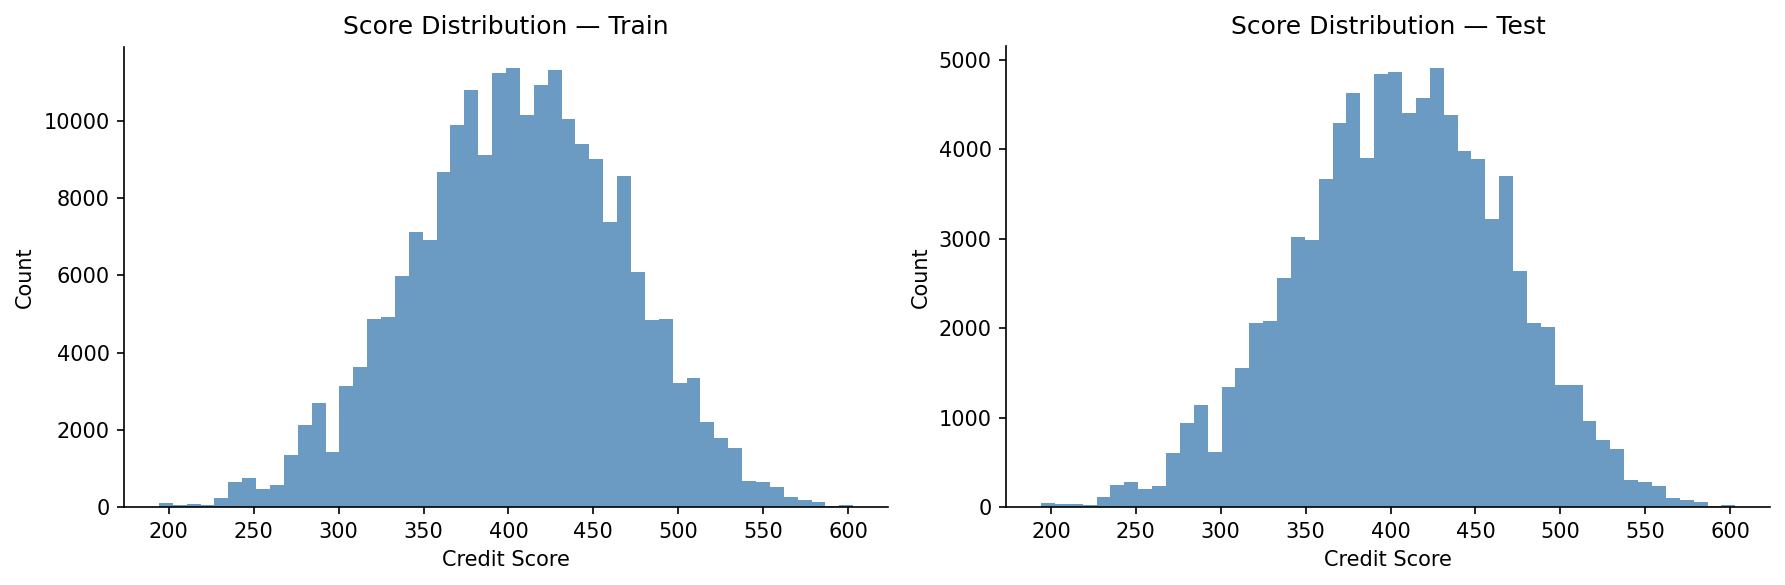

In [19]:
# Step 6: compute credit scores manually from logistic probabilities
factor = 50 / np.log(2)
offset = 600 - factor * np.log(20)

def prob_to_score(prob_default):
    odds_good = (1 - prob_default) / (prob_default + 1e-10)
    return offset + factor * np.log(odds_good)

train_probs = lr.predict_proba(X_train)[:, 1]
test_probs  = lr.predict_proba(X_test)[:, 1]

train_scores = prob_to_score(train_probs)
test_scores  = prob_to_score(test_probs)

print("Train score distribution:")
print(pd.Series(train_scores).describe().round(1).to_string())
print()
print("Test score distribution:")
print(pd.Series(test_scores).describe().round(1).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, scores, lab in zip(axes,
                            [train_scores, test_scores],
                            ['Train', 'Test']):
    ax.hist(scores, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Count')
    ax.set_title(f'Score Distribution — {lab}')
plt.tight_layout()
savefig('score_distribution.png')
plt.show()

In [21]:
# Step 7: XGBoost comparison model
import xgboost as xgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb_model.fit(X_train, y_train, verbose=False)

print("XGBoost training complete.")

scale_pos_weight: 11.39
XGBoost training complete.


Saved: xgb_feature_importance.png


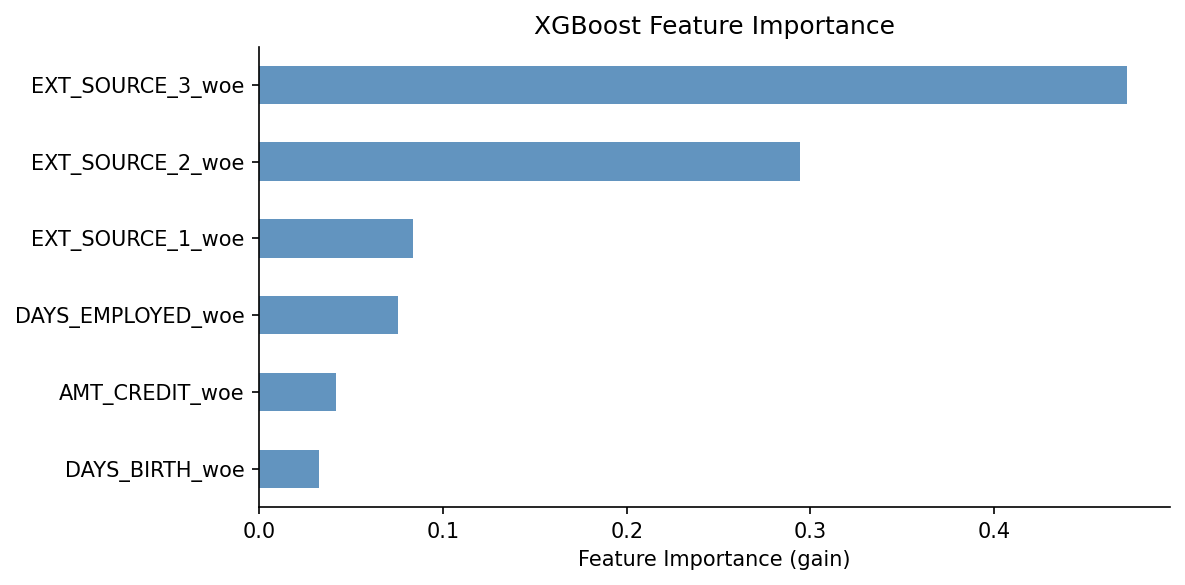


Feature importance values:
EXT_SOURCE_3_woe    0.4721
EXT_SOURCE_2_woe    0.2942
EXT_SOURCE_1_woe    0.0837
DAYS_EMPLOYED_woe   0.0757
AMT_CREDIT_woe      0.0417
DAYS_BIRTH_woe      0.0325


In [22]:
# Step 7: XGBoost feature importance
importance = pd.Series(xgb_model.feature_importances_,
                        index=selected_woe_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importance.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
savefig('xgb_feature_importance.png')
plt.show()

print("\nFeature importance values:")
print(importance.sort_values(ascending=False).to_string())

In [23]:
# Step 8: model evaluation
from sklearn.metrics import roc_auc_score, roc_curve

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1

def ks_stat(y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return (tpr - fpr).max()

lr_probs  = lr.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

lr_gini  = gini(y_test, lr_probs)
xgb_gini = gini(y_test, xgb_probs)
lr_ks    = ks_stat(y_test, lr_probs)
xgb_ks   = ks_stat(y_test, xgb_probs)

results = pd.DataFrame({
    'Model':  ['Logistic Regression', 'XGBoost'],
    'Gini':   [lr_gini,  xgb_gini],
    'KS':     [lr_ks,    xgb_ks],
    'AUC':    [(lr_gini + 1) / 2, (xgb_gini + 1) / 2]
})

print("Model comparison:")
print(results.to_string(index=False))
print()
print(f"Gini lift of XGBoost over logistic: {(xgb_gini - lr_gini):.4f}")

Model comparison:
              Model   Gini     KS    AUC
Logistic Regression 0.4521 0.3339 0.7261
            XGBoost 0.4588 0.3416 0.7294

Gini lift of XGBoost over logistic: 0.0067


Saved: roc_comparison.png


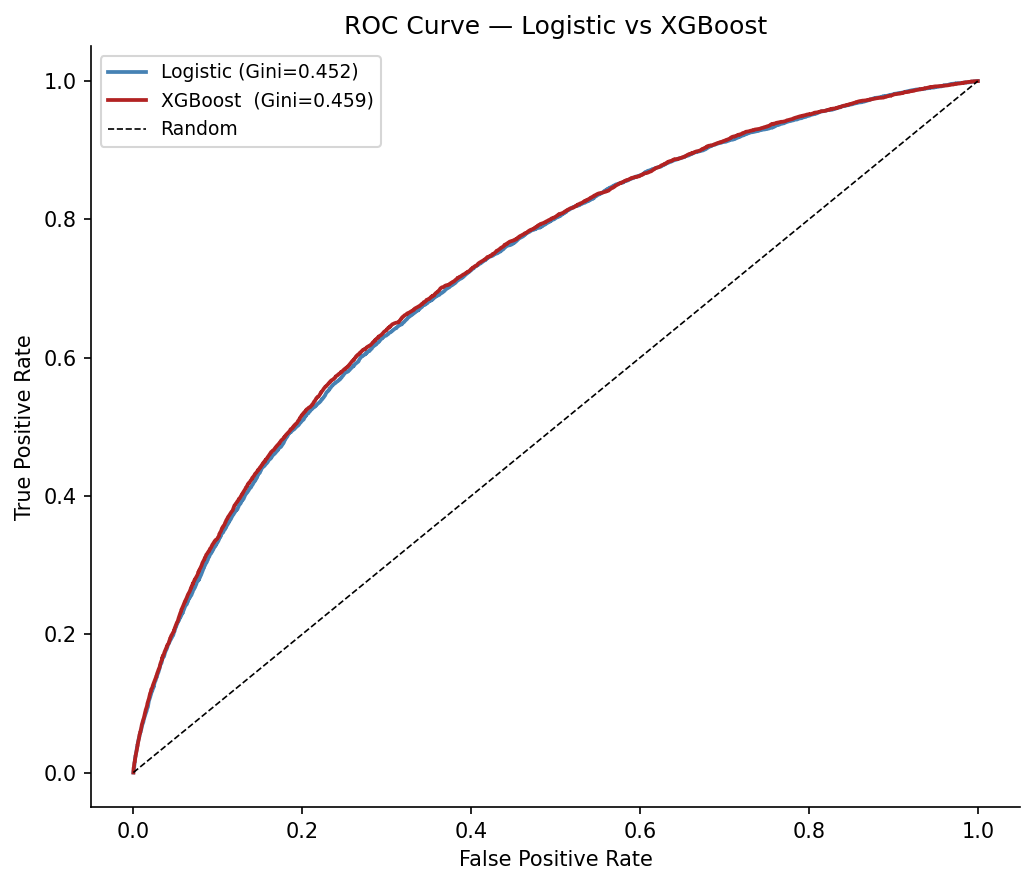

In [24]:
# Step 8: ROC curve comparison
fig, ax = plt.subplots(figsize=(7, 6))

for probs, label, color in [
    (lr_probs,  f'Logistic (Gini={lr_gini:.3f})',  'steelblue'),
    (xgb_probs, f'XGBoost  (Gini={xgb_gini:.3f})', 'firebrick')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=1.8, label=label)

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic vs XGBoost')
ax.legend(fontsize=9)
plt.tight_layout()
savefig('roc_comparison.png')
plt.show()

## Model Performance

| Model | Gini | KS | AUC |
|---|---|---|---|
| Logistic Regression (Scorecard) | 45.2% | 33.4% | 72.6% |
| XGBoost | 45.9% | 34.2% | 72.9% |

Gini lift of XGBoost over logistic: 0.67pp. Both models fall within the
40-60% industry benchmark range for retail scorecards. The marginal performance
gap does not justify sacrificing scorecard interpretability for regulatory purposes.
KS below 40% reflects the constrained 6-feature input set; a production model
incorporating full bureau tradeline data would improve separation.

Saved: calibration_plot.png


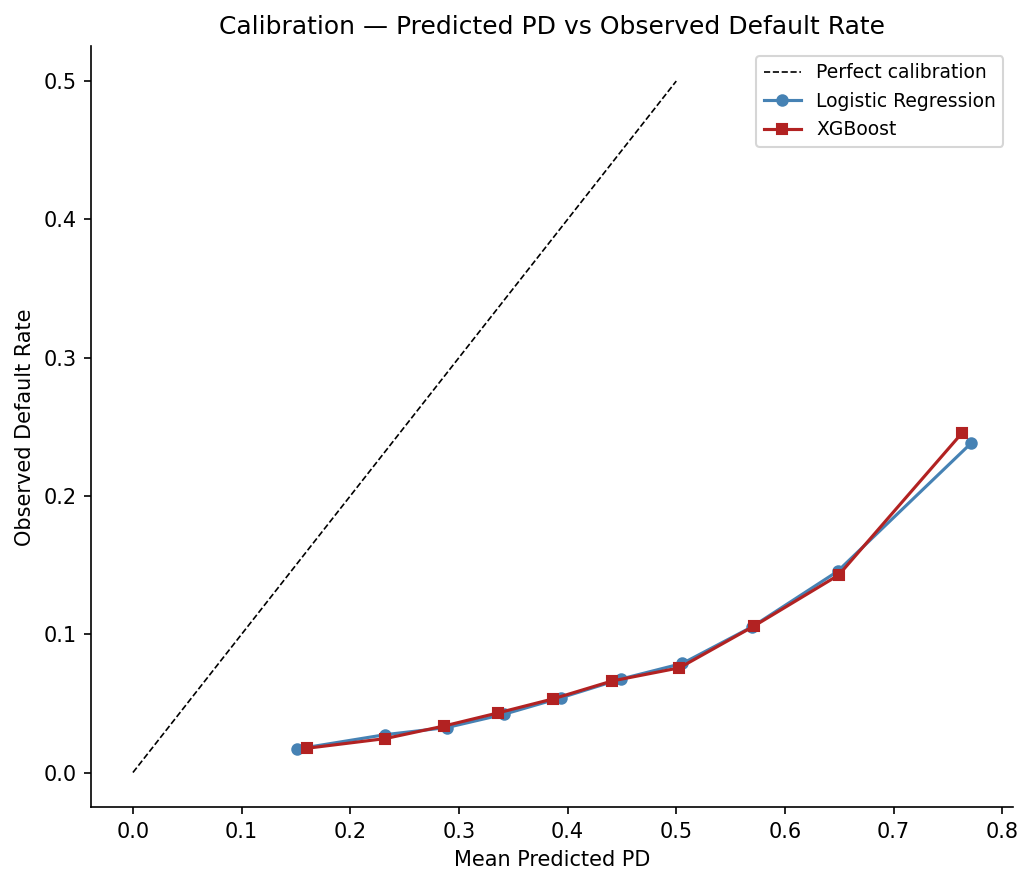

In [25]:
# Step 9: calibration plot
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 0.5], [0, 0.5], 'k--', linewidth=0.8, label='Perfect calibration')

for probs, label, color, marker in [
    (lr_probs,  'Logistic Regression', 'steelblue', 'o'),
    (xgb_probs, 'XGBoost',             'firebrick', 's')
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs,
                                             n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, color=color, marker=marker,
            linewidth=1.5, markersize=5, label=label)

ax.set_xlabel('Mean Predicted PD')
ax.set_ylabel('Observed Default Rate')
ax.set_title('Calibration — Predicted PD vs Observed Default Rate')
ax.legend(fontsize=9)
plt.tight_layout()
savefig('calibration_plot.png')
plt.show()

In [26]:
# Step 9: calibration table
print("Calibration by decile (Logistic Regression):")
frac_pos_lr, mean_pred_lr = calibration_curve(y_test, lr_probs,
                                               n_bins=10, strategy='quantile')
cal_df = pd.DataFrame({
    'mean_predicted_pd': mean_pred_lr,
    'observed_default_rate': frac_pos_lr,
    'abs_error': np.abs(mean_pred_lr - frac_pos_lr)
})
print(cal_df.round(4).to_string(index=False))
print(f"\nMean absolute calibration error: {cal_df['abs_error'].mean():.4f}")

Calibration by decile (Logistic Regression):
 mean_predicted_pd  observed_default_rate  abs_error
            0.1510                 0.0170     0.1340
            0.2322                 0.0274     0.2048
            0.2890                 0.0325     0.2565
            0.3416                 0.0422     0.2995
            0.3943                 0.0542     0.3402
            0.4493                 0.0676     0.3816
            0.5057                 0.0789     0.4268
            0.5698                 0.1053     0.4644
            0.6484                 0.1454     0.5030
            0.7711                 0.2380     0.5331

Mean absolute calibration error: 0.3544


In [27]:
# Step 9: recalibrate logistic model using Platt scaling
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr_calibrated = CalibratedClassifierCV(lr_base, method='sigmoid', cv=5)
lr_calibrated.fit(X_train, y_train)

lr_cal_probs = lr_calibrated.predict_proba(X_test)[:, 1]

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, lr_cal_probs,
                                                  n_bins=10, strategy='quantile')
cal_df2 = pd.DataFrame({
    'mean_predicted_pd':      mean_pred_cal,
    'observed_default_rate':  frac_pos_cal,
    'abs_error':              np.abs(mean_pred_cal - frac_pos_cal)
})
print("Calibration by decile (Logistic + Platt scaling):")
print(cal_df2.round(4).to_string(index=False))
print(f"\nMean absolute calibration error: {cal_df2['abs_error'].mean():.4f}")

Calibration by decile (Logistic + Platt scaling):
 mean_predicted_pd  observed_default_rate  abs_error
            0.0158                 0.0170     0.0012
            0.0262                 0.0274     0.0011
            0.0348                 0.0325     0.0023
            0.0440                 0.0422     0.0018
            0.0544                 0.0541     0.0003
            0.0672                 0.0677     0.0005
            0.0827                 0.0787     0.0040
            0.1044                 0.1056     0.0012
            0.1398                 0.1454     0.0056
            0.2379                 0.2380     0.0001

Mean absolute calibration error: 0.0018


Saved: calibration_plot.png


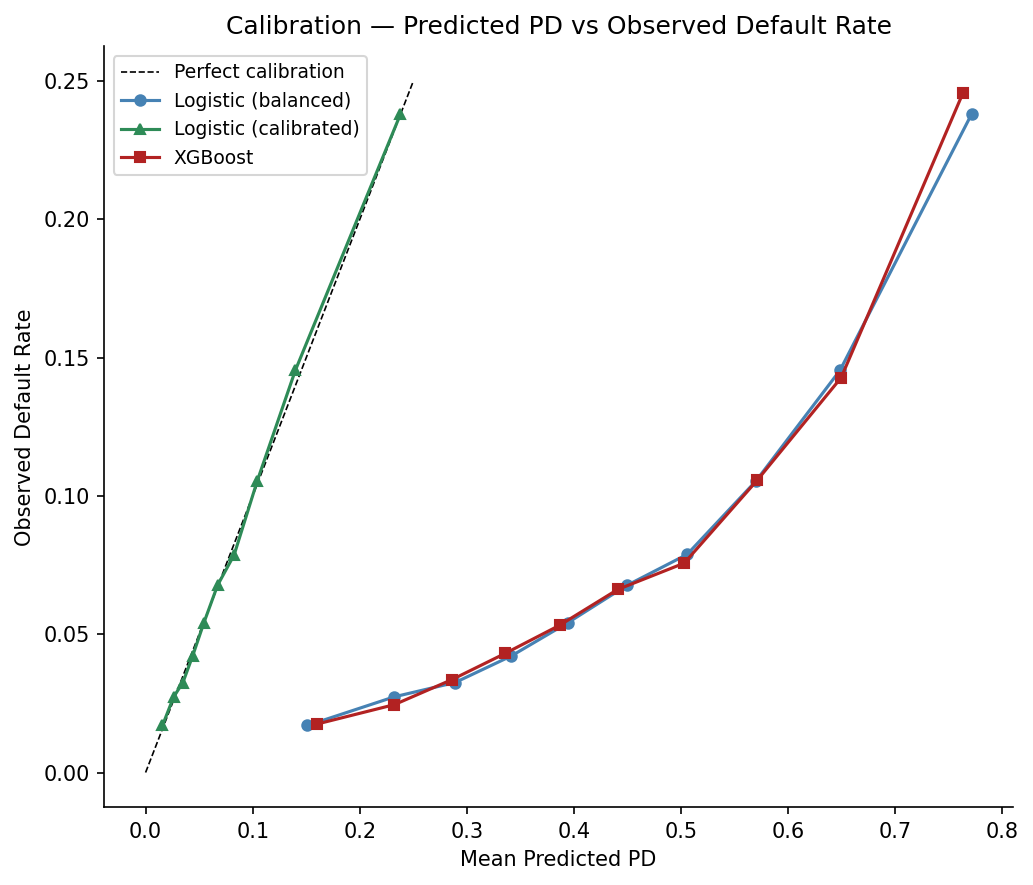

In [28]:
# Step 9: calibration plot with recalibrated model
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 0.25], [0, 0.25], 'k--', linewidth=0.8, label='Perfect calibration')

for probs, label, color, marker in [
    (lr_probs,      'Logistic (balanced)',     'steelblue', 'o'),
    (lr_cal_probs,  'Logistic (calibrated)',   'seagreen',  '^'),
    (xgb_probs,     'XGBoost',                 'firebrick', 's')
]:
    frac_pos, mean_pred = calibration_curve(y_test, probs,
                                             n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, color=color, marker=marker,
            linewidth=1.5, markersize=5, label=label)

ax.set_xlabel('Mean Predicted PD')
ax.set_ylabel('Observed Default Rate')
ax.set_title('Calibration — Predicted PD vs Observed Default Rate')
ax.legend(fontsize=9)
plt.tight_layout()
savefig('calibration_plot.png')
plt.show()

## Calibration

The logistic model with class_weight='balanced' produced severe miscalibration:
mean absolute error 0.354, with predicted PDs 3-5x above observed default rates.
Cause: balanced weighting shifts the decision boundary to capture defaulters but
inflates predicted probabilities above true rates.

Fix: Platt scaling (CalibratedClassifierCV, sigmoid, cv=5) remaps model outputs
to observed default rates. Post-calibration mean absolute error: 0.0018.
Predicted PDs are now suitable for provisioning and capital calculation purposes.

In [29]:
# Step 10: decision threshold analysis
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25]

rows = []
for thresh in thresholds:
    preds = (lr_cal_probs >= thresh).astype(int)
    defaults_captured = preds[y_test == 1].mean()
    approval_rate     = (preds == 0).mean()
    precision         = y_test[preds == 1].mean() if preds.sum() > 0 else 0
    rows.append({
        'Threshold':          thresh,
        'Defaults Captured':  defaults_captured,
        'Approval Rate':      approval_rate,
        'Precision (flagged)': precision
    })

threshold_df = pd.DataFrame(rows)
print("Decision threshold analysis:")
print(threshold_df.to_string(index=False, float_format='{:.3f}'.format))

Decision threshold analysis:
 Threshold  Defaults Captured  Approval Rate  Precision (flagged)
     0.050              0.847          0.411                0.116
     0.100              0.559          0.738                0.173
     0.150              0.347          0.875                0.224
     0.200              0.211          0.937                0.269
     0.250              0.123          0.968                0.312


Saved: threshold_analysis.png


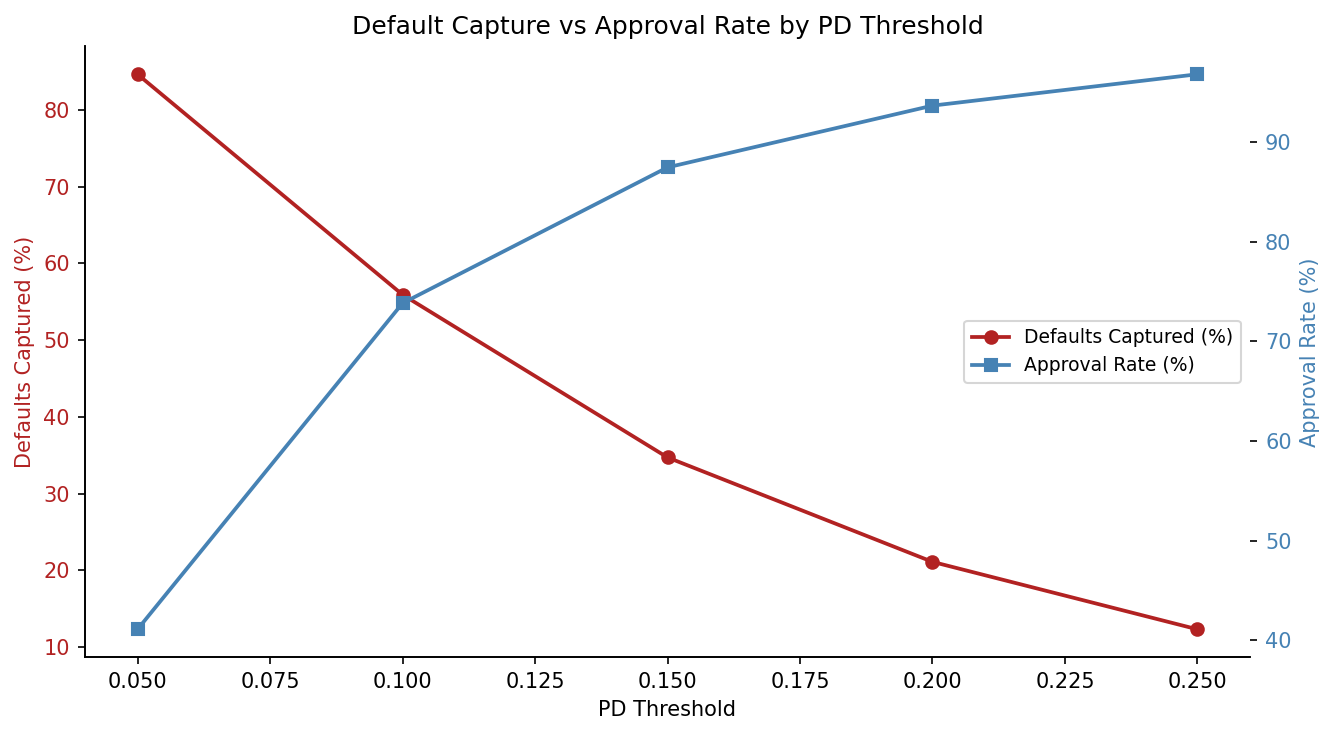

In [30]:
# Step 10: threshold trade-off plot
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(threshold_df['Threshold'],
         threshold_df['Defaults Captured'] * 100,
         'o-', color='firebrick', linewidth=1.8, label='Defaults Captured (%)')
ax1.set_xlabel('PD Threshold')
ax1.set_ylabel('Defaults Captured (%)', color='firebrick')
ax1.tick_params(axis='y', labelcolor='firebrick')

ax2 = ax1.twinx()
ax2.plot(threshold_df['Threshold'],
         threshold_df['Approval Rate'] * 100,
         's-', color='steelblue', linewidth=1.8, label='Approval Rate (%)')
ax2.set_ylabel('Approval Rate (%)', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Default Capture vs Approval Rate by PD Threshold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=9)
plt.tight_layout()
savefig('threshold_analysis.png')
plt.show()